
# 01 - Exploratory Data Analysis (EDA)

## Dataset: hourlySteps_clean.csv

### Programación para la Ciencia de Datos

## Objetivo
Desarrollar un análisis exploratorio completo sobre registros horarios de actividad física.

Este notebook incluye:
- Limpieza y validación.
- Visualización exploratoria.
- Detección de patrones.
- Análisis estadístico.
- PCA.
- Clustering.
- Interpretación técnica.

---

## Indicadores cubiertos
- Técnicas no supervisadas.
- Visualizaciones avanzadas.
- Interpretación técnica.
- Código reproducible.
- Análisis experimental.


In [ ]:

# ========================================
# LIBRERÍAS
# ========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

RANDOM_STATE = 42


In [ ]:

# ========================================
# CARGA DEL DATASET
# ========================================

df = pd.read_csv("hourlySteps_clean.csv")

print(df.shape)

df.head()


(21273, 7)


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.428148
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1,-0.428148
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.428148
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.428148
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.428148


In [ ]:

# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21273 entries, 0 to 21272
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                21273 non-null  float64
 1   ActivityHour      21273 non-null  object 
 2   StepTotal         21273 non-null  float64
 3   Hora              21273 non-null  int64  
 4   Dia               21273 non-null  object 
 5   FinDeSemana       21273 non-null  int64  
 6   StepTotal_scaled  21273 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


In [ ]:

# Estadísticas descriptivas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,21273.0,4.893813e+09,2.419428e+09,1.503960e+09,2.347168e+09,4.558610e+09,6.962181e+09,8.877689e+09
StepTotal,21273.0,2.880527e+02,6.728030e+02,0.000000e+00,0.000000e+00,1.000000e+01,2.910000e+02,1.056500e+04
Hora,21273.0,1.141033e+01,6.922465e+00,0.000000e+00,5.000000e+00,1.100000e+01,1.700000e+01,2.300000e+01
FinDeSemana,21273.0,3.165515e-01,4.651417e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
StepTotal_scaled,21273.0,1.870465e-17,1.000024e+00,-4.281483e-01,-4.281483e-01,-4.132848e-01,4.380738e-03,1.527518e+01



# Valores Nulos


In [ ]:

df.isnull().sum()


,0
Id,0
ActivityHour,0
StepTotal,0
Hora,0
Dia,0
FinDeSemana,0
StepTotal_scaled,0



# Duplicados


In [ ]:

duplicates = df.duplicated().sum()

print(f"Duplicados encontrados: {duplicates}")


Duplicados encontrados: 0



# Distribución de StepTotal


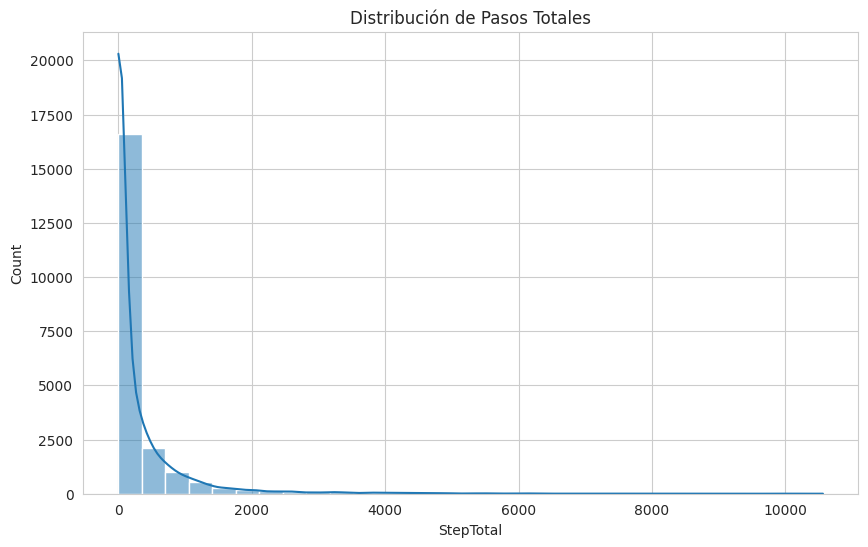

In [ ]:

plt.figure(figsize=(10,6))

sns.histplot(
    df['StepTotal'],
    bins=30,
    kde=True
)

plt.title("Distribución de Pasos Totales")

plt.show()



# Actividad por Hora


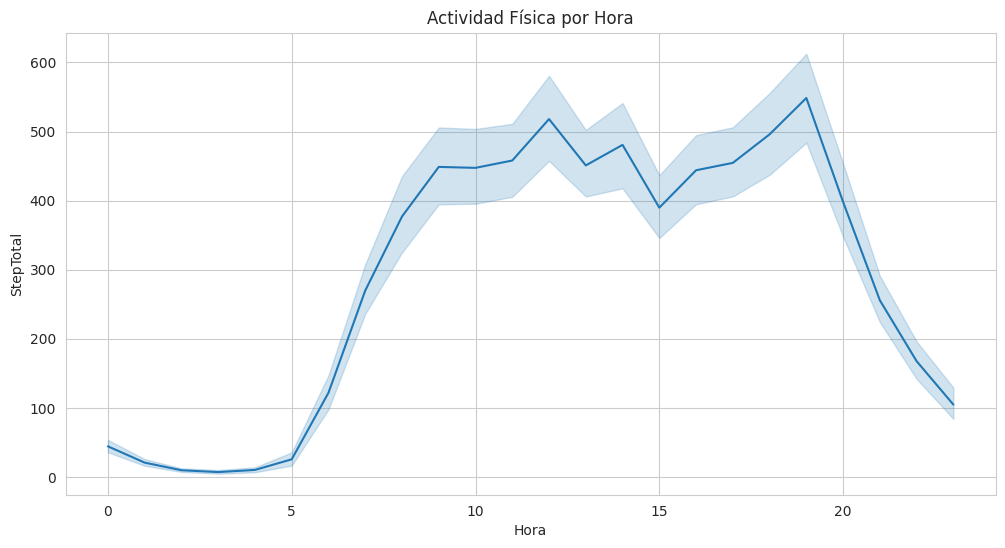

In [ ]:

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Hora',
    y='StepTotal'
)

plt.title("Actividad Física por Hora")

plt.show()



# Actividad Fin de Semana


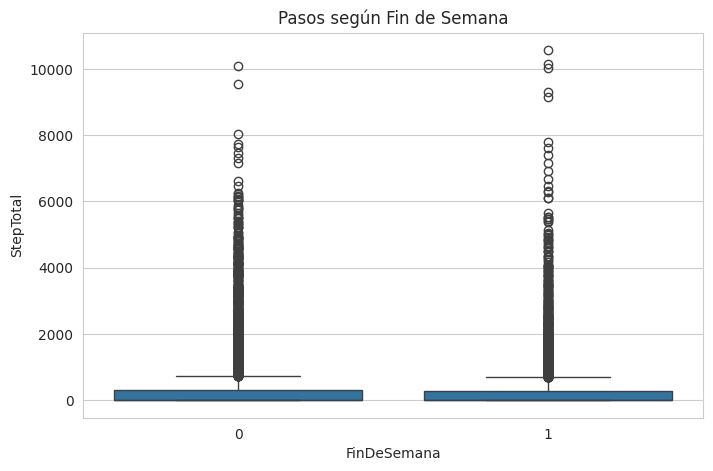

In [ ]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='FinDeSemana',
    y='StepTotal'
)

plt.title("Pasos según Fin de Semana")

plt.show()



# Correlación


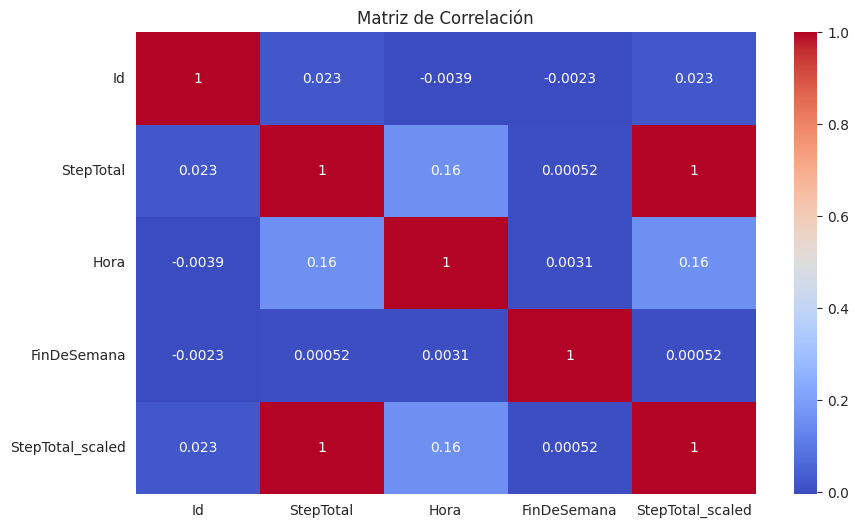

In [ ]:

numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de Correlación")

plt.show()



# Detección de Outliers


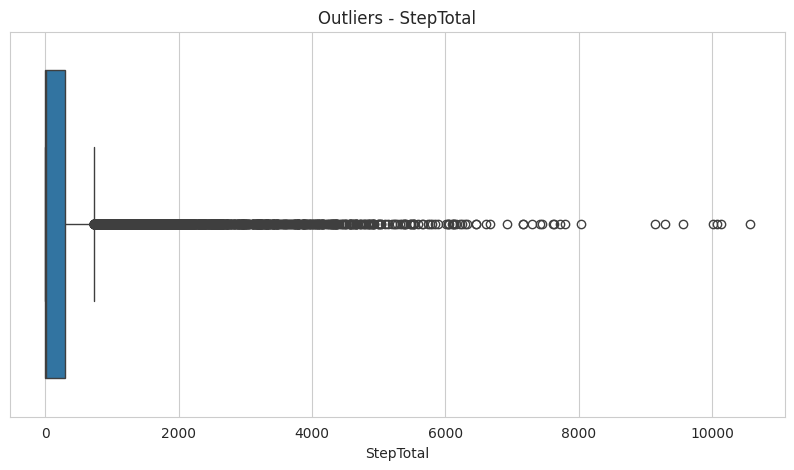

In [ ]:

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['StepTotal']
)

plt.title("Outliers - StepTotal")

plt.show()



# Escalamiento


In [ ]:

features = [
    'Hora',
    'FinDeSemana',
    'StepTotal_scaled'
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-1.64834366,  1.46936846, -0.42814834],
       [-1.50388304,  1.46936846, -0.42814834],
       [-1.35942242,  1.46936846, -0.42814834],
       [-1.2149618 ,  1.46936846, -0.42814834],
       [-1.07050119,  1.46936846, -0.42814834]])


# PCA


In [ ]:

pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=['PCA1', 'PCA2']
)

print("Varianza explicada:")
print(pca.explained_variance_ratio_)


Varianza explicada:
[0.38663509 0.33332657]


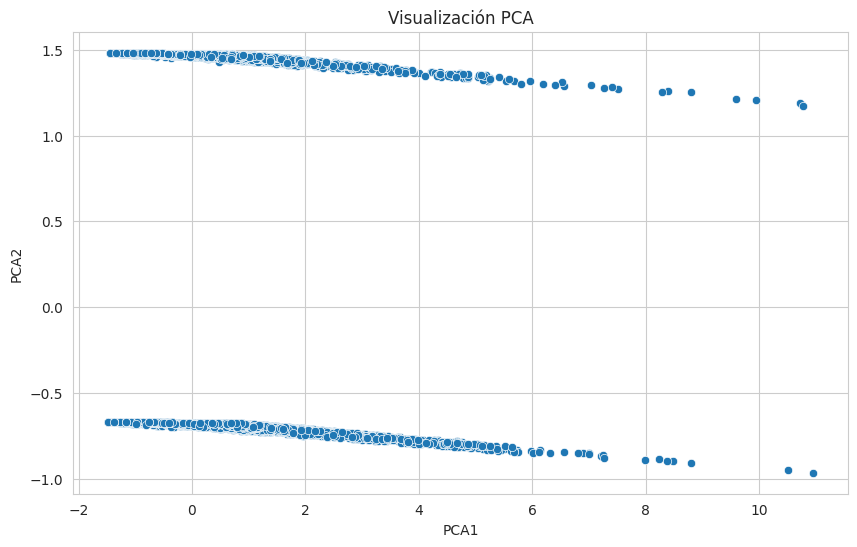

In [ ]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2'
)

plt.title("Visualización PCA")

plt.show()



# Clustering con K-Means


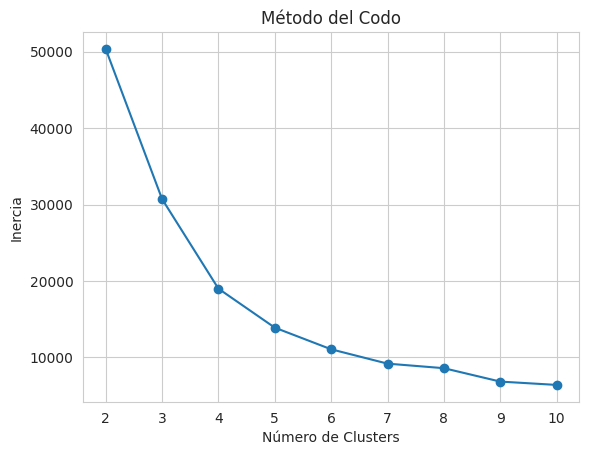

In [ ]:

inertia = []

k_values = range(2,11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')

plt.title("Método del Codo")

plt.xlabel("Número de Clusters")

plt.ylabel("Inercia")

plt.show()


In [ ]:

kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE
)

clusters = kmeans.fit_predict(X_scaled)

pca_df['Cluster'] = clusters

score = silhouette_score(X_scaled, clusters)

print(f"Silhouette Score: {score:.4f}")


Silhouette Score: 0.4541


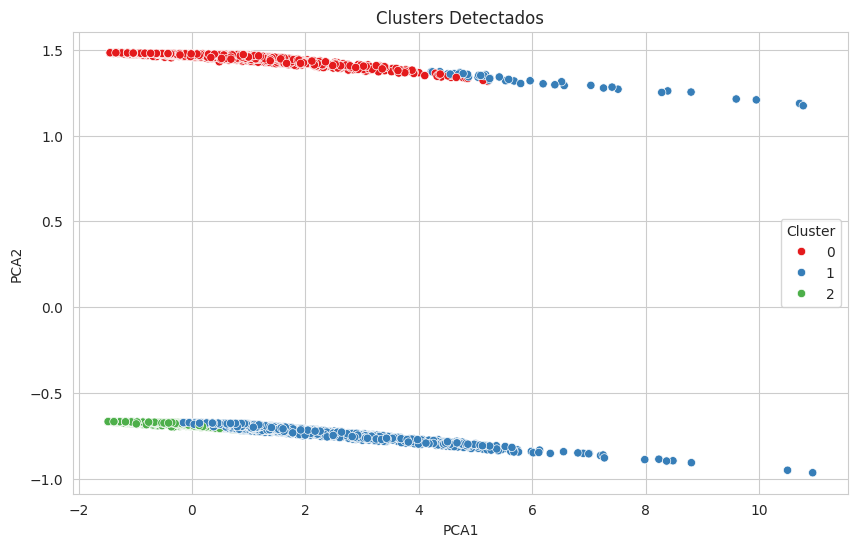

In [ ]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)

plt.title("Clusters Detectados")

plt.show()



# Conclusiones

## Hallazgos
- Existen patrones horarios en la actividad física.
- El fin de semana modifica el comportamiento de actividad.
- PCA permitió visualizar estructuras ocultas.
- K-Means detectó agrupaciones naturales.

## Impacto
- Puede utilizarse para segmentación de usuarios.
- Permite construir modelos predictivos.
- Facilita análisis de hábitos físicos.
